<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/hazop_workshop_with_neqsim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Facilitator-ready HAZOP workshop with NeqSim

This notebook turns a calculated gas-condensate process into a structured HAZOP
workshop. It combines native NeqSim HAZOP objects with facilitator-reviewed causes,
consequences, safeguards, quantitative scenario calculations, risk ranking, and an
action register.

The example is educational screening, not a completed HAZOP, design verification,
SIL determination, or regulatory approval. A multidisciplinary team remains
responsible for node definition, guide-word review, safeguards, independence,
assumptions, actions, and close-out.

## Learning objectives

After completing the notebook, you can:

1. build a composable NeqSim inlet-separation and export-compression process;
2. generate native HAZOP node candidates from a `ProcessSystem`;
3. apply IEC 61882 guide words to defined design intent;
4. quantify overpressure, high-temperature, and gas-blow-by deviations;
5. distinguish safeguards from recommendations and operating assumptions;
6. rank scenarios and produce a traceable HAZOP action register.

## Study basis and standards context

IEC 61882:2016 defines the guide-word HAZOP method and its preparation,
examination, documentation, and follow-up workflow. ISO 17776:2016 provides a
major-accident-hazard framework for offshore production installations. IEC 61511
applies when a HAZOP recommendation becomes a safety-instrumented-function
requirement.

This notebook uses public synthetic data. Pressures are absolute (`bara`), flow is
mass flow unless stated otherwise, and NeqSim uses an SRK equation of state with
classic mixing rules. Design limits are illustrative and must be replaced by the
approved project design basis.

In [1]:
%pip install -q "neqsim==3.16.0" "pandas>=2.2" "matplotlib>=3.8" "scipy>=1.11"

Dependencies are installed and importable.


## Imports and runtime evidence

In [2]:
import importlib.metadata
import json
import platform
import sys

import jpype
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib import patches

from neqsim import jneqsim as ns

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.fontsize": 9,
    }
)

runtime = {
    "neqsim": importlib.metadata.version("neqsim"),
    "python": platform.python_version(),
    "java": str(jpype.java.lang.System.getProperty("java.version")),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "matplotlib": matplotlib.__version__,
}
display(pd.DataFrame([runtime]).T.rename(columns={0: "version"}))

,version
neqsim,3.16.0
python,3.12.13
java,17.0.19
numpy,2.5.1
pandas,3.0.5
matplotlib,3.11.1


## Reference process and HAZOP nodes

The process contains five calculation objects:

- a 72 bara gas-condensate feed;
- an inlet choke to a 55 bara HP separator;
- gas export compression to 95 bara;
- aftercooling to 40 °C;
- separated condensate as a named product stream.

The HAZOP workshop groups these into three nodes: inlet pressure control, HP
separation, and compression/aftercooling.

In [3]:
COMPONENTS = [
    ("nitrogen", 0.010),
    ("CO2", 0.020),
    ("methane", 0.700),
    ("ethane", 0.080),
    ("propane", 0.060),
    ("i-butane", 0.020),
    ("n-butane", 0.025),
    ("i-pentane", 0.015),
    ("n-pentane", 0.020),
    ("n-hexane", 0.020),
    ("n-heptane", 0.020),
    ("n-octane", 0.010),
]


def build_reference_process(
    flow_kg_hr=120_000.0,
    feed_pressure_bara=72.0,
    separator_pressure_bara=55.0,
    export_pressure_bara=95.0,
):
    fluid = ns.thermo.system.SystemSrkEos(308.15, feed_pressure_bara)
    for component, mole_fraction in COMPONENTS:
        fluid.addComponent(component, mole_fraction)
    fluid.createDatabase(True)
    fluid.setMixingRule(2)
    fluid.setMultiPhaseCheck(True)

    feed = ns.process.equipment.stream.Stream("Feed stream", fluid)
    feed.setFlowRate(flow_kg_hr, "kg/hr")

    inlet_choke = ns.process.equipment.valve.ThrottlingValve(
        "Inlet choke",
        feed,
    )
    inlet_choke.setOutletPressure(separator_pressure_bara, "bara")

    separator = ns.process.equipment.separator.Separator(
        "HP separator",
        inlet_choke.getOutletStream(),
    )

    compressor = ns.process.equipment.compressor.Compressor(
        "Export compressor",
        separator.getGasOutStream(),
    )
    compressor.setOutletPressure(export_pressure_bara, "bara")
    compressor.setIsentropicEfficiency(0.75)

    aftercooler = ns.process.equipment.heatexchanger.Cooler(
        "Export aftercooler",
        compressor.getOutletStream(),
    )
    aftercooler.setOutTemperature(313.15)

    process = ns.process.processmodel.ProcessSystem()
    for unit in [feed, inlet_choke, separator, compressor, aftercooler]:
        process.add(unit)
    process.run()

    return {
        "process": process,
        "feed": feed,
        "inlet_choke": inlet_choke,
        "separator": separator,
        "compressor": compressor,
        "aftercooler": aftercooler,
    }


case = build_reference_process()
process = case["process"]
feed = case["feed"]
inlet_choke = case["inlet_choke"]
separator = case["separator"]
compressor = case["compressor"]
aftercooler = case["aftercooler"]

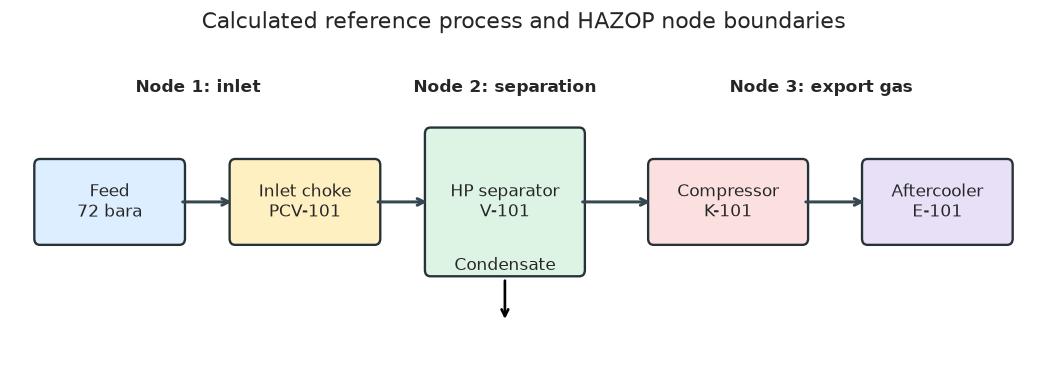

In [4]:
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.set_xlim(0, 11)
ax.set_ylim(0, 3)
ax.axis("off")

equipment = [
    (0.3, 1.15, 1.5, 0.7, "Feed\n72 bara", "#DCEEFF"),
    (2.4, 1.15, 1.5, 0.7, "Inlet choke\nPCV-101", "#FFF0C2"),
    (4.5, 0.85, 1.6, 1.3, "HP separator\nV-101", "#DDF3E4"),
    (6.9, 1.15, 1.6, 0.7, "Compressor\nK-101", "#FCE0E0"),
    (9.2, 1.15, 1.5, 0.7, "Aftercooler\nE-101", "#E7E0F7"),
]
for x_pos, y_pos, width, height, label, color in equipment:
    box = patches.FancyBboxPatch(
        (x_pos, y_pos),
        width,
        height,
        boxstyle="round,pad=0.06",
        facecolor=color,
        edgecolor="#263238",
        linewidth=1.4,
    )
    ax.add_patch(box)
    ax.text(
        x_pos + width / 2,
        y_pos + height / 2,
        label,
        ha="center",
        va="center",
        fontsize=10,
    )

for start, end in [(1.8, 2.4), (3.9, 4.5), (6.1, 6.9), (8.5, 9.2)]:
    ax.annotate(
        "",
        xy=(end, 1.5),
        xytext=(start, 1.5),
        arrowprops={"arrowstyle": "->", "lw": 1.8, "color": "#37474F"},
    )

ax.annotate(
    "Condensate",
    xy=(5.3, 0.35),
    xytext=(5.3, 0.85),
    ha="center",
    arrowprops={"arrowstyle": "->", "lw": 1.6},
)
ax.text(2.0, 2.55, "Node 1: inlet", ha="center", weight="bold")
ax.text(5.3, 2.55, "Node 2: separation", ha="center", weight="bold")
ax.text(8.7, 2.55, "Node 3: export gas", ha="center", weight="bold")
ax.set_title("Calculated reference process and HAZOP node boundaries", pad=10)
plt.show()

## Base-case process results

In [5]:
base_results = pd.DataFrame(
    [
        {
            "quantity": "Feed mass flow",
            "value": feed.getFlowRate("kg/hr"),
            "unit": "kg/h",
        },
        {
            "quantity": "Separator pressure",
            "value": separator.getGasOutStream().getPressure("bara"),
            "unit": "bara",
        },
        {
            "quantity": "Separator temperature",
            "value": separator.getGasOutStream().getTemperature("C"),
            "unit": "°C",
        },
        {
            "quantity": "Gas product",
            "value": separator.getGasOutStream().getFlowRate("kg/hr"),
            "unit": "kg/h",
        },
        {
            "quantity": "Condensate product",
            "value": separator.getLiquidOutStream().getFlowRate("kg/hr"),
            "unit": "kg/h",
        },
        {
            "quantity": "Compressor discharge temperature",
            "value": compressor.getOutletStream().getTemperature("C"),
            "unit": "°C",
        },
        {
            "quantity": "Compressor power",
            "value": compressor.getPower("MW"),
            "unit": "MW",
        },
        {
            "quantity": "Aftercooler duty",
            "value": aftercooler.getDuty() / 1.0e6,
            "unit": "MW",
        },
    ]
)
base_results["value"] = base_results["value"].astype(float).round(4)
display(base_results)

,quantity,value,unit
0,Feed mass flow,120000.0000,kg/h
1,Separator pressure,55.0000,bara
2,Separator temperature,29.5417,°C
3,Gas product,74307.1104,kg/h
4,Condensate product,45692.8896,kg/h
5,Compressor discharge temperature,76.5871,°C
6,Compressor power,1.6621,MW
7,Aftercooler duty,-2.1210,MW


In [6]:
feed_flow = feed.getFlowRate("kg/hr")
product_flow = (
    separator.getGasOutStream().getFlowRate("kg/hr")
    + separator.getLiquidOutStream().getFlowRate("kg/hr")
)
mass_balance_error = abs(product_flow - feed_flow) / feed_flow

composition_sum = sum(value for _, value in COMPONENTS)
balance_checks = pd.DataFrame(
    [
        {
            "check": "Feed composition sum",
            "value": composition_sum,
            "criterion": "1.0 ± 1e-12",
            "pass": abs(composition_sum - 1.0) < 1.0e-12,
        },
        {
            "check": "Separator mass closure",
            "value": mass_balance_error,
            "criterion": "< 1e-8 relative",
            "pass": mass_balance_error < 1.0e-8,
        },
        {
            "check": "Pressure ordering",
            "value": compressor.getOutletStream().getPressure("bara"),
            "criterion": "95 > 55 bara",
            "pass": (
                compressor.getOutletStream().getPressure("bara")
                > separator.getGasOutStream().getPressure("bara")
            ),
        },
    ]
)
display(balance_checks)

,check,value,criterion,pass
0,Feed composition sum,1.000000e+00,1.0 ± 1e-12,True
1,Separator mass closure,2.789117e-14,< 1e-8 relative,True
2,Pressure ordering,9.500000e+01,95 > 55 bara,True


## HAZOP method

A deviation is formed from a guide word and a process parameter:

$$
\text{Deviation} = \text{Guide word} + \text{Process parameter}
$$

Risk ranking is kept deliberately transparent:

$$
R = L \times S
$$

where $L$ is an illustrative likelihood category from 1 to 5, $S$ is an
illustrative consequence-severity category from 1 to 5, and $R$ is not a
calibrated quantitative risk measure. The project risk matrix governs real work.

In [7]:
guide_words = pd.DataFrame(
    [
        ("NO", "Complete absence of design intent"),
        ("MORE", "Quantitative increase"),
        ("LESS", "Quantitative decrease"),
        ("AS WELL AS", "Additional material, phase, or function"),
        ("PART OF", "Incomplete composition or function"),
        ("REVERSE", "Opposite direction or sequence"),
        ("OTHER THAN", "Substitution or different state"),
    ],
    columns=["guide word", "meaning"],
)
display(guide_words)

,guide word,meaning
0,NO,Complete absence of design intent
1,MORE,Quantitative increase
2,LESS,Quantitative decrease
3,AS WELL AS,"Additional material, phase, or function"
4,PART OF,Incomplete composition or function
5,REVERSE,Opposite direction or sequence
6,OTHER THAN,Substitution or different state


## Native node discovery

`HAZOPTemplate.fromProcessSystem` discovers calculation objects and their
connectivity. This is a useful preparation aid, but it does not replace node
boundary selection by the HAZOP team.

In [8]:
HAZOPTemplate = jpype.JClass(
    "neqsim.process.safety.hazid.HAZOPTemplate"
)
GuideWord = jpype.JClass(
    "neqsim.process.safety.hazid.HAZOPTemplate$GuideWord"
)
Parameter = jpype.JClass(
    "neqsim.process.safety.hazid.HAZOPTemplate$Parameter"
)

native_nodes = list(HAZOPTemplate.fromProcessSystem(process))
native_node_table = pd.DataFrame(
    [
        {
            "candidate node": str(node.getNodeId()),
            "generated design intent": str(node.getDesignIntent()),
        }
        for node in native_nodes
    ]
)
display(native_node_table)

,candidate node,generated design intent
0,Node-01: Feed stream (Stream),Normal operation of Feed stream
1,Node-02: Inlet choke (ThrottlingValve),Normal operation of Inlet choke; inlet(s): Feed stream; outlet(s): Inlet choke out stream
2,Node-03: HP separator (Separator),"Normal operation of HP separator; inlet(s): Inlet choke out stream; outlet(s): gasOutStream, liquidOutStream"
3,Node-04: Export compressor (Compressor),Normal operation of Export compressor; inlet(s): gasOutStream; outlet(s): Export compressor out stream
4,Node-05: Export aftercooler (Cooler),Normal operation of Export aftercooler; inlet(s): Export compressor out stream; outlet(s): outStream


### Mandatory human review of generated rows

NeqSim 3.16.0 contains a generic consequence catalogue. For example, the current
auto-populator can assign a pump-deadhead consequence to `NO FLOW` even for a
stream or throttling-valve node. That gap is tracked in
[equinor/neqsim#2652](https://github.com/equinor/neqsim/issues/2652).

Therefore this notebook uses native worksheet objects but fills each consequence
with a facilitator-reviewed, equipment-specific row.

## Facilitator-reviewed deviations

In [9]:
reviewed_deviations = [
    {
        "node": "N1 Inlet pressure control",
        "guide_word": GuideWord.NO,
        "parameter": Parameter.FLOW,
        "cause": "PCV-101 fails closed or upstream ESD is activated",
        "consequence": "Production stop; upstream pressure rise",
        "safeguard": "Low-flow alarm; upstream pressure protection",
        "recommendation": "Verify blocked-in upstream inventory and restart procedure",
        "likelihood": 3,
        "severity": 3,
        "owner": "Process",
    },
    {
        "node": "N1 Inlet pressure control",
        "guide_word": GuideWord.MORE,
        "parameter": Parameter.FLOW,
        "cause": "PCV-101 fails open or upstream pressure increases",
        "consequence": "Separator overload and pressure rise",
        "safeguard": "FHH; PSHH trip; PSV",
        "recommendation": "Confirm maximum inflow and vessel response time",
        "likelihood": 3,
        "severity": 4,
        "owner": "Technical safety",
    },
    {
        "node": "N1 Inlet pressure control",
        "guide_word": GuideWord.REVERSE,
        "parameter": Parameter.FLOW,
        "cause": "Upstream isolation with failed check function",
        "consequence": "Reverse gas flow and upstream inventory transfer",
        "safeguard": "Check valve; ESD isolation",
        "recommendation": "Confirm reverse-flow case and valve tightness basis",
        "likelihood": 2,
        "severity": 3,
        "owner": "Piping",
    },
    {
        "node": "N2 HP separator",
        "guide_word": GuideWord.MORE,
        "parameter": Parameter.PRESSURE,
        "cause": "Blocked gas outlet with continuing inflow",
        "consequence": "PSHH demand followed by MAWP exceedance",
        "safeguard": "PSHH trip; ESDV-101; PSV-101",
        "recommendation": "Verify process safety time and end-to-end ESD response",
        "likelihood": 3,
        "severity": 5,
        "owner": "Technical safety",
    },
    {
        "node": "N2 HP separator",
        "guide_word": GuideWord.MORE,
        "parameter": Parameter.LEVEL,
        "cause": "LCV-101 fails closed or liquid outlet is blocked",
        "consequence": "Liquid carry-over to export compressor",
        "safeguard": "LAHH; inlet trip; compressor scrubber",
        "recommendation": "Quantify dynamic level rise and carry-over tolerance",
        "likelihood": 3,
        "severity": 4,
        "owner": "Process",
    },
    {
        "node": "N2 HP separator",
        "guide_word": GuideWord.LESS,
        "parameter": Parameter.LEVEL,
        "cause": "LCV-101 fails open or level measurement is biased low",
        "consequence": "High-pressure gas blow-by to the LP system",
        "safeguard": "LALL; valve travel limit; LP PSV",
        "recommendation": "Check LP gas load for credible blow-by fractions",
        "likelihood": 3,
        "severity": 5,
        "owner": "Process",
    },
    {
        "node": "N2 HP separator",
        "guide_word": GuideWord.AS_WELL_AS,
        "parameter": Parameter.COMPOSITION,
        "cause": "Water or solids arrive with the production fluid",
        "consequence": "Hydrate, erosion, corrosion, or unstable level control",
        "safeguard": "Water detection; sand monitoring; chemical injection",
        "recommendation": "Add water/sand operating envelopes and response actions",
        "likelihood": 4,
        "severity": 3,
        "owner": "Flow assurance",
    },
    {
        "node": "N3 Export compression",
        "guide_word": GuideWord.LESS,
        "parameter": Parameter.FLOW,
        "cause": "Upstream trip or export restriction",
        "consequence": "Compressor approach to surge",
        "safeguard": "Anti-surge recycle; low-flow trip",
        "recommendation": "Verify transient surge margin and recycle capacity",
        "likelihood": 4,
        "severity": 4,
        "owner": "Rotating equipment",
    },
    {
        "node": "N3 Export compression",
        "guide_word": GuideWord.MORE,
        "parameter": Parameter.TEMPERATURE,
        "cause": "Low efficiency or aftercooler loss",
        "consequence": "High discharge temperature and downstream material demand",
        "safeguard": "TAHH; compressor trip; cooler duty monitoring",
        "recommendation": "Confirm discharge-temperature envelope",
        "likelihood": 3,
        "severity": 4,
        "owner": "Rotating equipment",
    },
    {
        "node": "N3 Export compression",
        "guide_word": GuideWord.MORE,
        "parameter": Parameter.PRESSURE,
        "cause": "Export valve closes while compressor continues",
        "consequence": "High discharge pressure and recycle/relief demand",
        "safeguard": "PAHH trip; recycle; PSV",
        "recommendation": "Verify settle-out and blocked-discharge cases",
        "likelihood": 2,
        "severity": 5,
        "owner": "Technical safety",
    },
    {
        "node": "N3 Export compression",
        "guide_word": GuideWord.PART_OF,
        "parameter": Parameter.COMPOSITION,
        "cause": "Liquid carry-over from V-101",
        "consequence": "Compressor damage and vibration",
        "safeguard": "LAHH trip; inlet scrubber; vibration trip",
        "recommendation": "Define allowable liquid carry-over and detection coverage",
        "likelihood": 2,
        "severity": 5,
        "owner": "Rotating equipment",
    },
    {
        "node": "N3 Export compression",
        "guide_word": GuideWord.NO,
        "parameter": Parameter.FLOW,
        "cause": "Check valve closed or export line blocked",
        "consequence": "Rapid discharge pressure rise and compressor trip",
        "safeguard": "PAHH trip; recycle; PSV",
        "recommendation": "Test trip sequence against process safety time",
        "likelihood": 2,
        "severity": 5,
        "owner": "Automation",
    },
]

design_intents = {
    "N1 Inlet pressure control": (
        "Reduce feed pressure while maintaining stable forward flow"
    ),
    "N2 HP separator": (
        "Separate gas and condensate within pressure and level limits"
    ),
    "N3 Export compression": (
        "Deliver dry gas at export pressure and acceptable temperature"
    ),
}

hazop_templates = {}
for node_name, design_intent in design_intents.items():
    hazop_templates[node_name] = HAZOPTemplate(
        node_name,
        design_intent,
    )

for row in reviewed_deviations:
    hazop_templates[row["node"]].addDeviation(
        row["guide_word"],
        row["parameter"],
        row["cause"],
        row["consequence"],
        row["safeguard"],
        row["recommendation"],
    )

for node_name, template in hazop_templates.items():
    print(template.report())
    print()

HAZOP node: N1 Inlet pressure control
Design intent: Reduce feed pressure while maintaining stable forward flow
---------------------------------------------------
[01] NO + FLOW
     Cause       : PCV-101 fails closed or upstream ESD is activated
     Consequence : Production stop; upstream pressure rise
     Safeguard   : Low-flow alarm; upstream pressure protection
     Recommend.  : Verify blocked-in upstream inventory and restart procedure
[02] MORE + FLOW
     Cause       : PCV-101 fails open or upstream pressure increases
     Consequence : Separator overload and pressure rise
     Safeguard   : FHH; PSHH trip; PSV
     Recommend.  : Confirm maximum inflow and vessel response time
[03] REVERSE + FLOW
     Cause       : Upstream isolation with failed check function
     Consequence : Reverse gas flow and upstream inventory transfer
     Safeguard   : Check valve; ESD isolation
     Recommend.  : Confirm reverse-flow case and valve tightness basis


HAZOP node: N2 HP separator
Des

In [10]:
hazop_rows = []
for row in reviewed_deviations:
    risk_score = row["likelihood"] * row["severity"]
    if risk_score >= 15:
        risk_band = "High"
    elif risk_score >= 8:
        risk_band = "Medium"
    else:
        risk_band = "Low"

    hazop_rows.append(
        {
            "node": row["node"],
            "deviation": (
                f"{row['guide_word'].name()} "
                f"{row['parameter'].name()}"
            ),
            "cause": row["cause"],
            "consequence": row["consequence"],
            "existing safeguards": row["safeguard"],
            "L": row["likelihood"],
            "S": row["severity"],
            "risk": risk_score,
            "band": risk_band,
            "recommendation": row["recommendation"],
            "owner": row["owner"],
        }
    )

hazop_df = pd.DataFrame(hazop_rows)
display(
    hazop_df.sort_values(
        ["risk", "node"],
        ascending=[False, True],
    ).reset_index(drop=True)
)

,node,deviation,cause,consequence,existing safeguards,L,S,risk,band,recommendation,owner
0,N3 Export compression,LESS FLOW,Upstream trip or export restriction,Compressor approach to surge,Anti-surge recycle; low-flow trip,4,4,16,High,Verify transient surge margin and recycle capacity,Rotating equipment
1,N2 HP separator,MORE PRESSURE,Blocked gas outlet with continuing inflow,PSHH demand followed by MAWP exceedance,PSHH trip; ESDV-101; PSV-101,3,5,15,High,Verify process safety time and end-to-end ESD response,Technical safety
2,N2 HP separator,LESS LEVEL,LCV-101 fails open or level measurement is biased low,High-pressure gas blow-by to the LP system,LALL; valve travel limit; LP PSV,3,5,15,High,Check LP gas load for credible blow-by fractions,Process
3,N1 Inlet pressure control,MORE FLOW,PCV-101 fails open or upstream pressure increases,Separator overload and pressure rise,FHH; PSHH trip; PSV,3,4,12,Medium,Confirm maximum inflow and vessel response time,Technical safety
4,N2 HP separator,MORE LEVEL,LCV-101 fails closed or liquid outlet is blocked,Liquid carry-over to export compressor,LAHH; inlet trip; compressor scrubber,3,4,12,Medium,Quantify dynamic level rise and carry-over tolerance,Process
5,N2 HP separator,AS_WELL_AS COMPOSITION,Water or solids arrive with the production fluid,"Hydrate, erosion, corrosion, or unstable level control",Water detection; sand monitoring; chemical injection,4,3,12,Medium,Add water/sand operating envelopes and response actions,Flow assurance
6,N3 Export compression,MORE TEMPERATURE,Low efficiency or aftercooler loss,High discharge temperature and downstream material demand,TAHH; compressor trip; cooler duty monitoring,3,4,12,Medium,Confirm discharge-temperature envelope,Rotating equipment
7,N3 Export compression,MORE PRESSURE,Export valve closes while compressor continues,High discharge pressure and recycle/relief demand,PAHH trip; recycle; PSV,2,5,10,Medium,Verify settle-out and blocked-discharge cases,Technical safety
8,N3 Export compression,PART_OF COMPOSITION,Liquid carry-over from V-101,Compressor damage and vibration,LAHH trip; inlet scrubber; vibration trip,2,5,10,Medium,Define allowable liquid carry-over and detection coverage,Rotating equipment
9,N3 Export compression,NO FLOW,Check valve closed or export line blocked,Rapid discharge pressure rise and compressor trip,PAHH trip; recycle; PSV,2,5,10,Medium,Test trip sequence against process safety time,Automation


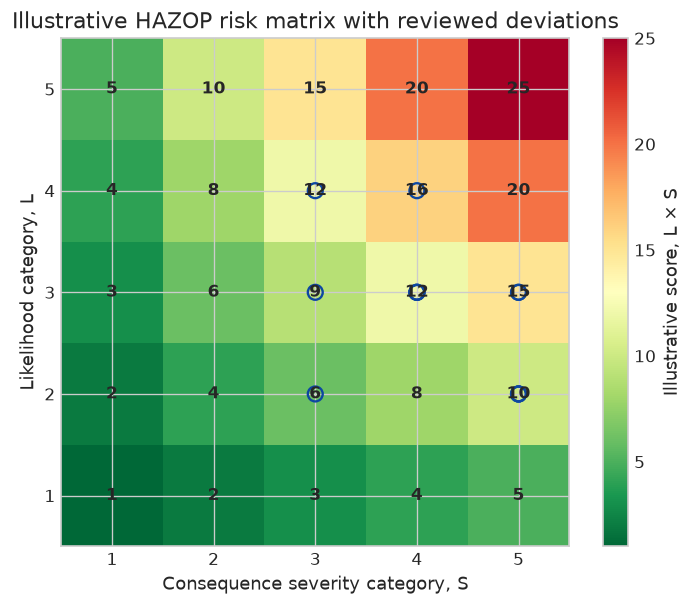

In [11]:
matrix = np.arange(1, 6)[:, None] * np.arange(1, 6)[None, :]
fig, ax = plt.subplots(figsize=(7.2, 5.5))
image = ax.imshow(
    matrix,
    origin="lower",
    cmap="RdYlGn_r",
    vmin=1,
    vmax=25,
    aspect="equal",
)
for likelihood in range(1, 6):
    for severity in range(1, 6):
        ax.text(
            severity - 1,
            likelihood - 1,
            str(likelihood * severity),
            ha="center",
            va="center",
            weight="bold",
        )

for _, row in hazop_df.iterrows():
    ax.scatter(
        row["S"] - 1,
        row["L"] - 1,
        s=80,
        facecolor="none",
        edgecolor="#0D47A1",
        linewidth=1.4,
    )

ax.set_xticks(range(5), labels=range(1, 6))
ax.set_yticks(range(5), labels=range(1, 6))
ax.set_xlabel("Consequence severity category, S")
ax.set_ylabel("Likelihood category, L")
ax.set_title("Illustrative HAZOP risk matrix with reviewed deviations")
fig.colorbar(image, ax=ax, label="Illustrative score, L × S")
plt.show()

## Quantification 1: blocked gas outlet

For an early constant-temperature real-gas screen, pressure rise in the gas space is
approximated by:

$$
\frac{dP}{dt} =
\frac{\dot{m}_{in} Z R T}{M V_g}
$$

where $\dot{m}_{in}$ is continuing gas inflow in kg/s, $Z$ is the NeqSim
compressibility factor, $M$ is gas molar mass in kg/mol, and $V_g$ is gas-space
volume in m³. This is deliberately conservative because no outlet flow is credited.
A rigorous design case requires dynamic heat transfer, level change, valve
characteristics, controller action, and relief flow.

In [12]:
gas_system = separator.getGasOutStream().getThermoSystem()
gas_system.init(3)

normal_pressure_bara = 55.0
pshh_pressure_bara = 62.0
mawp_bara = 75.0
gas_volume_m3 = 80.0
gas_inflow_kg_s = separator.getGasOutStream().getFlowRate("kg/sec")
gas_temperature_k = gas_system.getTemperature()
gas_molar_mass_kg_mol = gas_system.getMolarMass()
compressibility = gas_system.getZ()
gas_constant = 8.314462618

pressure_rate_pa_s = (
    gas_inflow_kg_s
    * compressibility
    * gas_constant
    * gas_temperature_k
    / gas_molar_mass_kg_mol
    / gas_volume_m3
)
pressure_rate_bara_s = pressure_rate_pa_s / 1.0e5

blocked_outlet_basis = pd.DataFrame(
    [
        ("Gas inflow", gas_inflow_kg_s, "kg/s"),
        ("Gas-space volume", gas_volume_m3, "m³"),
        ("Temperature", gas_temperature_k - 273.15, "°C"),
        ("Compressibility factor", compressibility, "-"),
        ("Gas molar mass", gas_molar_mass_kg_mol * 1000.0, "kg/kmol"),
        ("Screened pressure-rise rate", pressure_rate_bara_s, "bar/s"),
    ],
    columns=["quantity", "value", "unit"],
)
blocked_outlet_basis["value"] = (
    blocked_outlet_basis["value"].astype(float).round(4)
)
display(blocked_outlet_basis)

,quantity,value,unit
0,Gas inflow,20.6409,kg/s
1,Gas-space volume,80.0000,m³
2,Temperature,29.5417,°C
3,Compressibility factor,0.8539,-
4,Gas molar mass,20.8524,kg/kmol
5,Screened pressure-rise rate,0.2659,bar/s


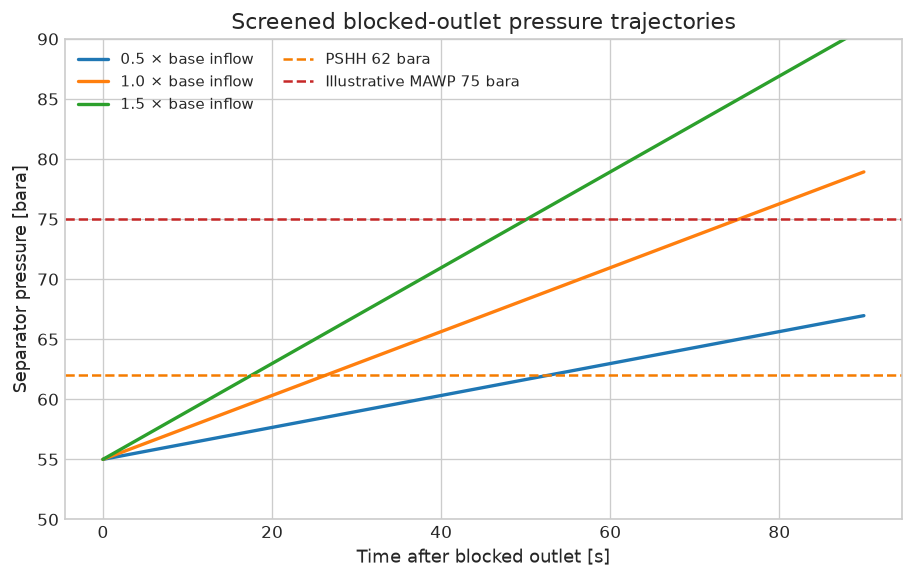

In [13]:
inflow_multipliers = [0.5, 1.0, 1.5]
time_s = np.linspace(0.0, 90.0, 181)
trajectories = []
for multiplier in inflow_multipliers:
    pressure = (
        normal_pressure_bara
        + multiplier * pressure_rate_bara_s * time_s
    )
    for time_value, pressure_value in zip(time_s, pressure):
        trajectories.append(
            {
                "time_s": time_value,
                "pressure_bara": pressure_value,
                "inflow_case": f"{multiplier:.1f} × base inflow",
            }
        )

pressure_df = pd.DataFrame(trajectories)
fig, ax = plt.subplots(figsize=(9, 5.2))
for case_name, group in pressure_df.groupby("inflow_case"):
    ax.plot(
        group["time_s"],
        group["pressure_bara"],
        linewidth=2,
        label=case_name,
    )
ax.axhline(
    pshh_pressure_bara,
    color="#F57C00",
    linestyle="--",
    label="PSHH 62 bara",
)
ax.axhline(
    mawp_bara,
    color="#C62828",
    linestyle="--",
    label="Illustrative MAWP 75 bara",
)
ax.set(
    xlabel="Time after blocked outlet [s]",
    ylabel="Separator pressure [bara]",
    title="Screened blocked-outlet pressure trajectories",
    ylim=(50, 90),
)
ax.legend(ncol=2)
plt.show()

In [14]:
safe_time_rows = []
for multiplier in inflow_multipliers:
    rate = multiplier * pressure_rate_bara_s
    time_to_pshh = (pshh_pressure_bara - normal_pressure_bara) / rate
    time_to_mawp = (mawp_bara - normal_pressure_bara) / rate
    response_budget = time_to_mawp - time_to_pshh
    safe_time_rows.append(
        {
            "inflow": f"{multiplier:.1f} × base",
            "time to PSHH [s]": time_to_pshh,
            "time to MAWP [s]": time_to_mawp,
            "response budget after PSHH [s]": response_budget,
        }
    )

safe_time_df = pd.DataFrame(safe_time_rows).round(2)
display(safe_time_df)

,inflow,time to PSHH [s],time to MAWP [s],response budget after PSHH [s]
0,0.5 × base,52.65,150.43,97.78
1,1.0 × base,26.33,75.22,48.89
2,1.5 × base,17.55,50.14,32.59


## Quantification 2: compressor high temperature

The discharge-temperature screen reruns the native NeqSim compressor over pressure
ratio and isentropic efficiency. It tests the HAZOP row `MORE TEMPERATURE` without
assuming an ideal-gas heat-capacity ratio.

In [15]:
compressor_rows = []
pressure_targets_bara = [75.0, 85.0, 95.0, 105.0, 115.0]
efficiencies = [0.65, 0.75, 0.82]

for efficiency in efficiencies:
    for pressure_target in pressure_targets_bara:
        trial_fluid = (
            separator.getGasOutStream().getThermoSystem().clone()
        )
        trial_feed = ns.process.equipment.stream.Stream(
            "Trial compressor feed",
            trial_fluid,
        )
        trial_feed.setFlowRate(
            separator.getGasOutStream().getFlowRate("kg/hr"),
            "kg/hr",
        )
        trial_compressor = ns.process.equipment.compressor.Compressor(
            "Trial compressor",
            trial_feed,
        )
        trial_compressor.setOutletPressure(
            pressure_target,
            "bara",
        )
        trial_compressor.setIsentropicEfficiency(efficiency)
        trial_process = ns.process.processmodel.ProcessSystem()
        trial_process.add(trial_feed)
        trial_process.add(trial_compressor)
        trial_process.run()
        compressor_rows.append(
            {
                "efficiency": efficiency,
                "outlet_pressure_bara": pressure_target,
                "outlet_temperature_C": (
                    trial_compressor.getOutletStream().getTemperature("C")
                ),
                "power_MW": trial_compressor.getPower("MW"),
            }
        )

compressor_screen = pd.DataFrame(compressor_rows)
display(compressor_screen.round(3))

,efficiency,outlet_pressure_bara,outlet_temperature_C,power_MW
0,0.65,75.0,58.548,1.055
1,0.65,85.0,70.469,1.505
2,0.65,95.0,81.160,1.918
3,0.65,105.0,90.855,2.301
4,0.65,115.0,99.727,2.658
5,0.75,75.0,55.955,0.914
6,0.75,85.0,66.829,1.304
7,0.75,95.0,76.587,1.662
8,0.75,105.0,85.438,1.994
9,0.75,115.0,93.538,2.304


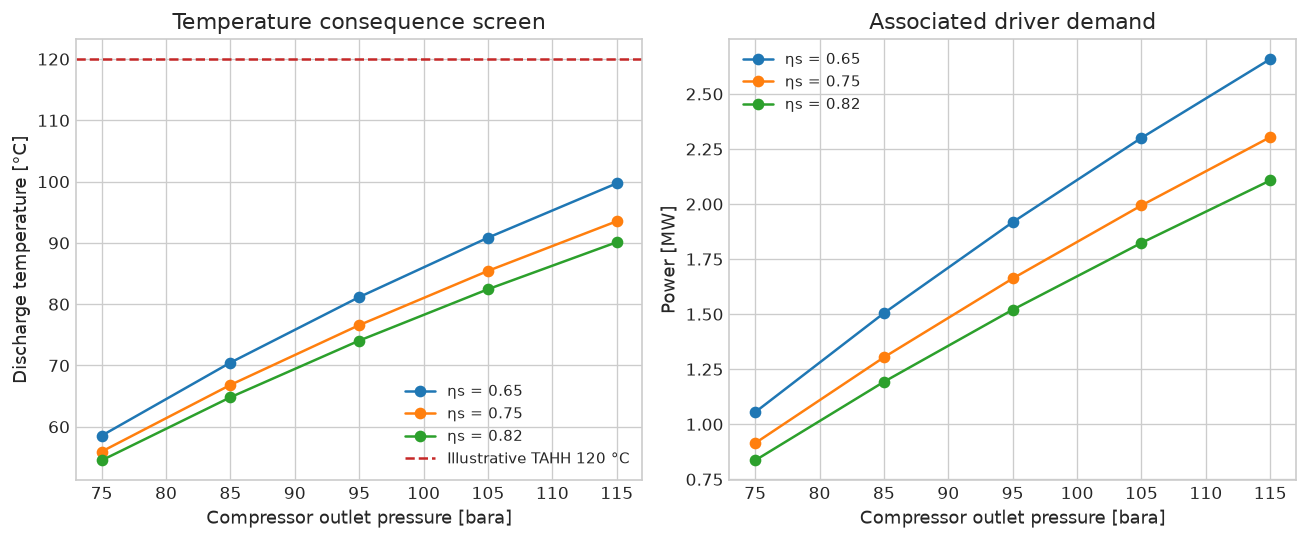

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for efficiency, group in compressor_screen.groupby("efficiency"):
    label = f"ηs = {efficiency:.2f}"
    axes[0].plot(
        group["outlet_pressure_bara"],
        group["outlet_temperature_C"],
        marker="o",
        label=label,
    )
    axes[1].plot(
        group["outlet_pressure_bara"],
        group["power_MW"],
        marker="o",
        label=label,
    )
axes[0].axhline(
    120.0,
    color="#C62828",
    linestyle="--",
    label="Illustrative TAHH 120 °C",
)
axes[0].set(
    xlabel="Compressor outlet pressure [bara]",
    ylabel="Discharge temperature [°C]",
    title="Temperature consequence screen",
)
axes[1].set(
    xlabel="Compressor outlet pressure [bara]",
    ylabel="Power [MW]",
    title="Associated driver demand",
)
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

## Quantification 3: separator low level and gas blow-by

Gas blow-by depends on valve capacity and transient level/interface behavior. At
HAZOP stage, the following transparent screen assumes that 5%, 10%, or 20% of the
HP separator gas stream passes through a failed-open liquid outlet into a 10 bara LP
system. NeqSim calculates the downstream flashed temperature and gas density.

In [17]:
blowby_fluid = separator.getGasOutStream().getThermoSystem().clone()
blowby_feed = ns.process.equipment.stream.Stream(
    "Gas blow-by feed",
    blowby_fluid,
)
blowby_feed.setFlowRate(
    separator.getGasOutStream().getFlowRate("kg/hr"),
    "kg/hr",
)
blowby_valve = ns.process.equipment.valve.ThrottlingValve(
    "Failed-open level valve",
    blowby_feed,
)
blowby_valve.setOutletPressure(10.0, "bara")
blowby_process = ns.process.processmodel.ProcessSystem()
blowby_process.add(blowby_feed)
blowby_process.add(blowby_valve)
blowby_process.run()

lp_temperature_c = blowby_valve.getOutletStream().getTemperature("C")
lp_density = (
    blowby_valve.getOutletStream()
    .getThermoSystem()
    .getDensity("kg/m3")
)

blowby_rows = []
for fraction in [0.05, 0.10, 0.20]:
    mass_rate = (
        fraction
        * separator.getGasOutStream().getFlowRate("kg/sec")
    )
    blowby_rows.append(
        {
            "credited blow-by fraction": fraction,
            "LP gas load [kg/s]": mass_rate,
            "LP actual volume [m³/s]": mass_rate / lp_density,
            "flashed LP temperature [°C]": lp_temperature_c,
        }
    )
blowby_df = pd.DataFrame(blowby_rows).round(3)
display(blowby_df)

,credited blow-by fraction,LP gas load [kg/s],LP actual volume [m³/s],flashed LP temperature [°C]
0,0.05,1.032,0.019,2.422
1,0.10,2.064,0.038,2.422
2,0.20,4.128,0.077,2.422


## Quantified action register

In [18]:
quantitative_evidence = {
    "MORE PRESSURE": (
        f"Base case reaches PSHH in "
        f"{safe_time_df.loc[1, 'time to PSHH [s]']:.1f} s and leaves "
        f"{safe_time_df.loc[1, 'response budget after PSHH [s]']:.1f} s "
        "before illustrative MAWP."
    ),
    "MORE TEMPERATURE": (
        f"Screened discharge temperature range is "
        f"{compressor_screen['outlet_temperature_C'].min():.1f}–"
        f"{compressor_screen['outlet_temperature_C'].max():.1f} °C."
    ),
    "LESS LEVEL": (
        f"At 10% blow-by, the LP system receives "
        f"{blowby_df.loc[1, 'LP gas load [kg/s]']:.2f} kg/s at "
        f"{lp_temperature_c:.1f} °C."
    ),
}

action_register = hazop_df[
    (hazop_df["risk"] >= 12)
    | hazop_df["deviation"].isin(quantitative_evidence)
].copy()
action_register["quantitative evidence"] = (
    action_register["deviation"]
    .map(quantitative_evidence)
    .fillna("Dedicated follow-up calculation required.")
)
action_register.insert(
    0,
    "action id",
    [f"HAZ-A-{index:03d}" for index in range(1, len(action_register) + 1)],
)
action_register["status"] = "Open"
display(
    action_register[
        [
            "action id",
            "node",
            "deviation",
            "risk",
            "recommendation",
            "owner",
            "quantitative evidence",
            "status",
        ]
    ].reset_index(drop=True)
)

,action id,node,deviation,risk,recommendation,owner,quantitative evidence,status
0,HAZ-A-001,N1 Inlet pressure control,MORE FLOW,12,Confirm maximum inflow and vessel response time,Technical safety,Dedicated follow-up calculation required.,Open
1,HAZ-A-002,N2 HP separator,MORE PRESSURE,15,Verify process safety time and end-to-end ESD response,Technical safety,Base case reaches PSHH in 26.3 s and leaves 48.9 s before illustrative MAWP.,Open
2,HAZ-A-003,N2 HP separator,MORE LEVEL,12,Quantify dynamic level rise and carry-over tolerance,Process,Dedicated follow-up calculation required.,Open
3,HAZ-A-004,N2 HP separator,LESS LEVEL,15,Check LP gas load for credible blow-by fractions,Process,"At 10% blow-by, the LP system receives 2.06 kg/s at 2.4 °C.",Open
4,HAZ-A-005,N2 HP separator,AS_WELL_AS COMPOSITION,12,Add water/sand operating envelopes and response actions,Flow assurance,Dedicated follow-up calculation required.,Open
5,HAZ-A-006,N3 Export compression,LESS FLOW,16,Verify transient surge margin and recycle capacity,Rotating equipment,Dedicated follow-up calculation required.,Open
6,HAZ-A-007,N3 Export compression,MORE TEMPERATURE,12,Confirm discharge-temperature envelope,Rotating equipment,Screened discharge temperature range is 54.5–99.7 °C.,Open
7,HAZ-A-008,N3 Export compression,MORE PRESSURE,10,Verify settle-out and blocked-discharge cases,Technical safety,Base case reaches PSHH in 26.3 s and leaves 48.9 s before illustrative MAWP.,Open


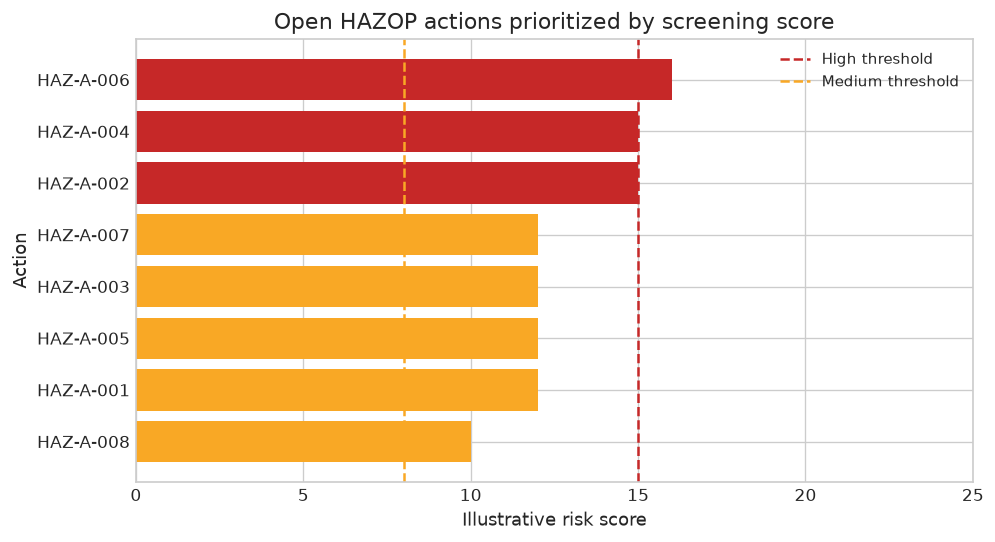

In [19]:
fig, ax = plt.subplots(figsize=(9, 4.8))
plot_actions = action_register.sort_values("risk")
colors = plot_actions["band"].map(
    {"High": "#C62828", "Medium": "#F9A825", "Low": "#2E7D32"}
)
ax.barh(
    plot_actions["action id"],
    plot_actions["risk"],
    color=colors,
)
ax.axvline(15, color="#C62828", linestyle="--", label="High threshold")
ax.axvline(8, color="#F9A825", linestyle="--", label="Medium threshold")
ax.set(
    xlabel="Illustrative risk score",
    ylabel="Action",
    title="Open HAZOP actions prioritized by screening score",
    xlim=(0, 25),
)
ax.legend()
plt.show()

## Validation and quality gates

In [20]:
validation = pd.DataFrame(
    [
        {
            "check": "Notebook uses pinned public NeqSim release",
            "result": runtime["neqsim"],
            "pass": runtime["neqsim"] == "3.16.0",
        },
        {
            "check": "All 12 composition fractions sum to unity",
            "result": composition_sum,
            "pass": abs(composition_sum - 1.0) < 1.0e-12,
        },
        {
            "check": "Separator total mass closure",
            "result": mass_balance_error,
            "pass": mass_balance_error < 1.0e-8,
        },
        {
            "check": "Reviewed HAZOP has at least 12 deviations",
            "result": len(hazop_df),
            "pass": len(hazop_df) >= 12,
        },
        {
            "check": "PSHH precedes MAWP in every inflow case",
            "result": bool(
                (
                    safe_time_df["time to PSHH [s]"]
                    < safe_time_df["time to MAWP [s]"]
                ).all()
            ),
            "pass": bool(
                (
                    safe_time_df["time to PSHH [s]"]
                    < safe_time_df["time to MAWP [s]"]
                ).all()
            ),
        },
        {
            "check": "Higher pressure increases compressor temperature",
            "result": (
                compressor_screen.groupby("efficiency")[
                    "outlet_temperature_C"
                ]
                .apply(lambda values: values.is_monotonic_increasing)
                .all()
            ),
            "pass": (
                compressor_screen.groupby("efficiency")[
                    "outlet_temperature_C"
                ]
                .apply(lambda values: values.is_monotonic_increasing)
                .all()
            ),
        },
        {
            "check": "Every prioritized action has an owner",
            "result": int(action_register["owner"].notna().sum()),
            "pass": action_register["owner"].notna().all(),
        },
    ]
)
display(validation)
assert validation["pass"].all()
print("All HAZOP notebook validation checks passed.")

All HAZOP notebook validation checks passed.


,check,result,pass
0,Notebook uses pinned public NeqSim release,3.16.0,True
1,All 12 composition fractions sum to unity,1.0,True
2,Separator total mass closure,0.0,True
3,Reviewed HAZOP has at least 12 deviations,12,True
4,PSHH precedes MAWP in every inflow case,True,True
5,Higher pressure increases compressor temperature,True,True
6,Every prioritized action has an owner,8,True


## Engineering interpretation and limitations

- The highest-ranked example deviations are HP-separator overpressure, low-level
  gas blow-by, and compressor low-flow/surge exposure.
- The blocked-outlet pressure model is a first-response screen, not a dynamic
  relief or blowdown calculation.
- The gas-blow-by fractions are explicit scenarios, not valve-capacity predictions.
- The compressor screen uses steady-state equilibrium thermodynamics and does not
  model anti-surge dynamics.
- Risk categories are illustrative. Do not transfer them into a live asset risk
  register without the approved company matrix and study team.
- Automatic consequence text requires equipment-aware review; see
  [NeqSim issue #2652](https://github.com/equinor/neqsim/issues/2652).

## Summary and suggested exercises

The notebook demonstrates the complete chain:

`calculated process → native node discovery → reviewed HAZOP rows → quantified consequences → action register`

Suggested extensions:

1. replace the constant-temperature pressure screen with dynamic vessel filling;
2. add valve-$C_v$ gas-blow-by capacity and LP-system PSV sizing;
3. connect the response budget to the companion barrier-performance notebook;
4. repeat the workshop for TEG regeneration or CO₂ compression;
5. export the action register to the project's governed HAZOP system.

## References

- [IEC 61882:2016 — HAZOP application guide](https://webstore.iec.ch/en/publication/24321)
- [IEC 61511 series — safety instrumented systems](https://webstore.iec.ch/en/publication/5527)
- [ISO 17776:2016 — major accident hazard management](https://www.iso.org/standard/63062.html)
- [NeqSim HAZOP documentation](https://equinor.github.io/neqsim/safety/HAZOP)
- [NeqSim issue #2652 — equipment-aware HAZOP auto-population](https://github.com/equinor/neqsim/issues/2652)